<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Smart Plan Recommendation System

---

### Background

Telecom Egypt (WE) serves thousands of subscribers across Egypt with internet plans that vary in speed, quota, and price. A key business challenge is **plan-subscriber mismatch** — subscribers enrolled in plans that do not reflect their actual usage and payment behavior.

This project simulates a real-world data science task at WE. You are part of the Data & AI team. Your mission is to build a machine learning model that analyzes subscriber profiles and recommends the most suitable plan action:

> **Upgrade** — the subscriber needs a bigger plan  
> **Downgrade** — the subscriber is over-paying for what they use  
> **Keep** — the current plan is a good fit

---

### Available Datasets

| Dataset | Description |
|---------|-------------|
| `Customer.csv` | Subscriber demographics and plan enrollment |
| `Subscription_Plan_Lkp.csv` | Plan details — quota, speed, and price |
| `Network_Elements.csv` | Infrastructure type per subscriber (VDSL, FTTH, etc.) |
| `Payments.csv` | Monthly payment transactions per subscriber |
| `Consumption_RG_LKP.csv` | Lookup table for consumption rating groups |

---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- You are expected to make decisions along the way. Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Load & Explore the Data

### Objective
Understand what data you have before touching it.

### Why This Step Matters
Before building any model, a data scientist must fully understand the data — its structure, quality, and distributions. Skipping EDA leads to wrong assumptions and poor models.

### What To Do
- Load all 5 datasets and print their shape and data types.
- Check for missing values in each table and decide how to handle them.
- Visualize key distributions:
  - `Customer`: `SUBSCRIBER_STATUS`, `CUSTOMER_CLASS`, `GENDER`
  - `Subscription_Plan_Lkp`: price range, speed range, quota sizes
  - `Payments`: revenue columns and monthly revenue trend
  - `Network_Elements`: breakdown of `TECHNOLOGY_TYPE`

**Expected Output:** At least 4 visualizations. Write a short observation below each one explaining what you see.


In [65]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [66]:
# ── Load Data ────────────────────────────────────────────────────────────────
customer = pd.read_csv("Customer.csv")
subscription_plan_lkp = pd.read_csv("Subscription_Plan_Lkp.csv")
network_elements = pd.read_csv("Network_Elements.csv")
payments = pd.read_csv("Payments.csv")
consumption_rg_lkp = pd.read_csv("Consumption_RG_LKP.csv")
datasets = {
    "Customer": customer,
    "Subscription Plan": subscription_plan_lkp,
    "Network Elements": network_elements,
    "Payments": payments,
    "Consumption Lookup": consumption_rg_lkp
}
datasets = {
    "Customer": customer,
    "Subscription Plan": subscription_plan_lkp,
    "Network Elements": network_elements,
    "Payments": payments,
    "Consumption Lookup": consumption_rg_lkp
}
for name, df in datasets.items():
    print("="*60)
    print(name)
    print("Shape:", df.shape)
    print("\nData Types")
    print(df.dtypes)

Customer
Shape: (9995, 17)

Data Types
SUBSCRIBER_ID#                    int64
ACCOUNT_ID#                       int64
CUSTOMER_ID#                      int64
GROUP_ID#                       float64
NAME                             object
SUBSCRIBER_STATUS                object
STATUS_DATE                      object
GENDER                           object
BIRTHDATE                        object
ID_TYPE                          object
NATIONALITY                      object
ACTIVATION_DATE                  object
CUSTOMER_CLASS                   object
SUBSCRIBER_TYPE                  object
SUBSCRIPTION_PLAN_FAMILY_ID#      int64
SUBSCRIPTION_PLAN_ID#             int64
SERVICE_NUMBER#                   int64
dtype: object
Subscription Plan
Shape: (108, 11)

Data Types
SUBSCRIPTION_PLAN_ID#                    int64
SUBSCRIPTION_PLAN_FAMILY_ID#             int64
SUBSCRIPTION_PLAN_DESC                  object
SUBSCRIPTION_PLAN_FAMILY_DESC           object
QUOTA                           

In [67]:
# ── Missing Values ────────────────────────────────────────────────────────────
for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.isnull().sum())

Customer
SUBSCRIBER_ID#                     0
ACCOUNT_ID#                        0
CUSTOMER_ID#                       0
GROUP_ID#                       9320
NAME                               0
SUBSCRIBER_STATUS                  0
STATUS_DATE                        0
GENDER                             0
BIRTHDATE                         61
ID_TYPE                            0
NATIONALITY                        0
ACTIVATION_DATE                    0
CUSTOMER_CLASS                     0
SUBSCRIBER_TYPE                    0
SUBSCRIPTION_PLAN_FAMILY_ID#       0
SUBSCRIPTION_PLAN_ID#              0
SERVICE_NUMBER#                    0
dtype: int64
Subscription Plan
SUBSCRIPTION_PLAN_ID#                  0
SUBSCRIPTION_PLAN_FAMILY_ID#           0
SUBSCRIPTION_PLAN_DESC                 0
SUBSCRIPTION_PLAN_FAMILY_DESC          0
QUOTA                                  0
SPEED                                  0
PRICE_PLAN_PRICE                       0
SUBSCRIPTION_PLAN_START_TIME           0
SUB

Index(['SUBSCRIBER_ID#', 'ACCOUNT_ID#', 'CUSTOMER_ID#', 'GROUP_ID#', 'NAME',
       'SUBSCRIBER_STATUS', 'STATUS_DATE', 'GENDER', 'BIRTHDATE', 'ID_TYPE',
       'NATIONALITY', 'ACTIVATION_DATE', 'CUSTOMER_CLASS', 'SUBSCRIBER_TYPE',
       'SUBSCRIPTION_PLAN_FAMILY_ID#', 'SUBSCRIPTION_PLAN_ID#',
       'SERVICE_NUMBER#'],
      dtype='object')


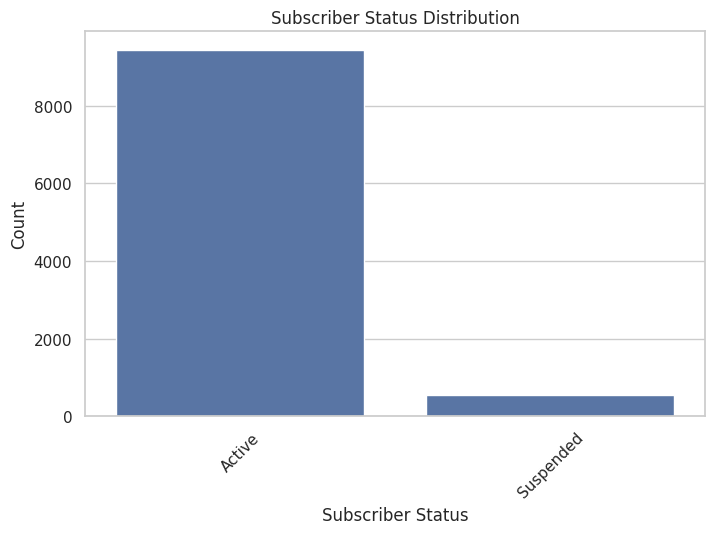

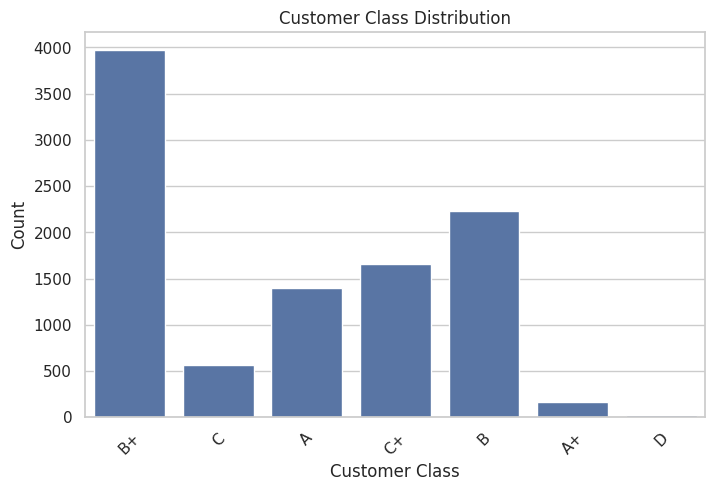

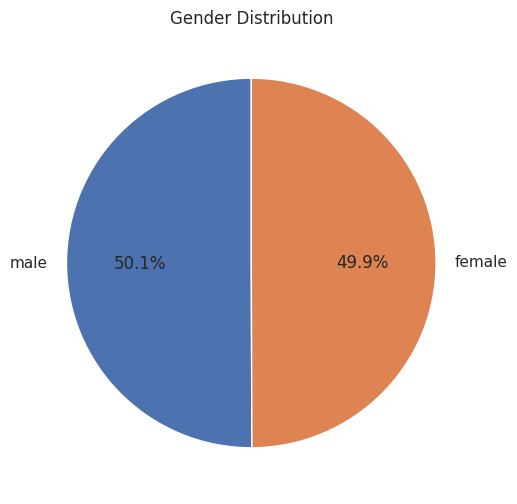

In [68]:
# ── EDA: Customer Table ──────────────────────────────────────────────────────
'''
Overview of the customer dataset using the following variables:

SUBSCRIBER_STATUS: A bar chart showing the distribution of customers according to their subscription status.
CUSTOMER_CLASS: A bar chart illustrating the number of customers in each customer class.
GENDER: A pie chart displaying the percentage distribution of customers by gender.

'''
print(customer.columns)
plt.figure(figsize=(8,5))
sns.countplot(data=customer, x="SUBSCRIBER_STATUS")

plt.title("Subscriber Status Distribution")
plt.xlabel("Subscriber Status")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()
#bar chart represents subscriber status, the active subscribers are more than the suspended ones
plt.figure(figsize=(8,5))
sns.countplot(data=customer, x="CUSTOMER_CLASS")
plt.title("Customer Class Distribution")
plt.xlabel("Customer Class")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()
#bar chart that represents distribution of customers in classes A+,A,B+,B,C+,C,D most of the costumers are in B+ class
gender_counts = customer["GENDER"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.show()
#pie chart that represents gender distribution male gender are more than female

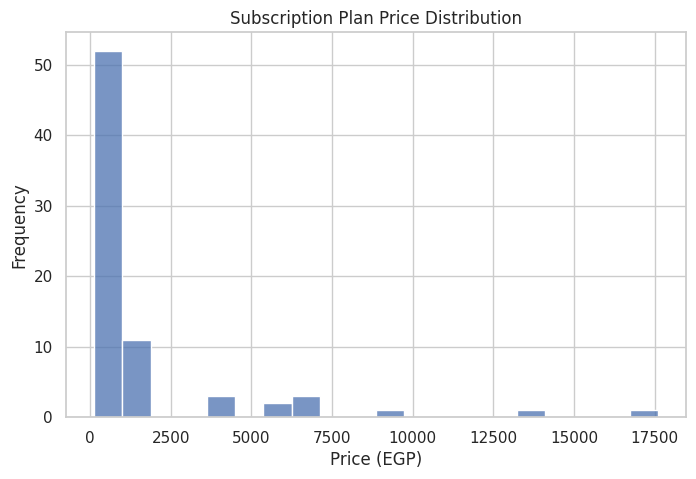

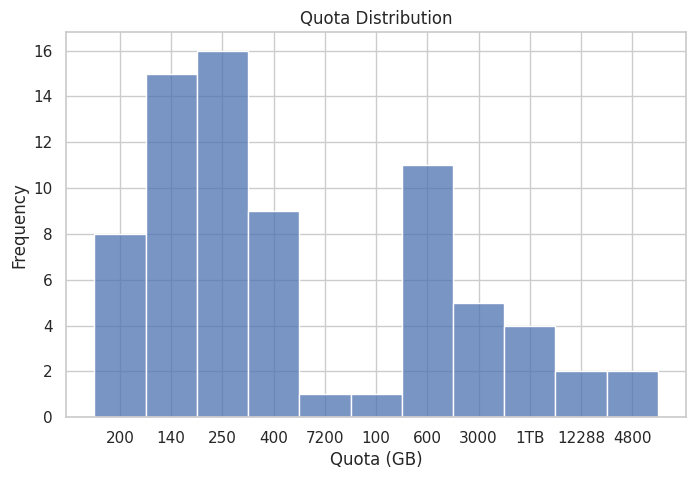

In [69]:
# ── EDA: Plans Table ─────────────────────────────────────────────────────────
'''
Overview of the PRICE_PLAN_PRICE and QUOTA variables for active subscription plans (PRICE_PLAN_PRICE > 0):

PRICE_PLAN_PRICE: A histogram showing the distribution of subscription plan prices (in EGP), illustrating how plan prices are spread across different price ranges.
QUOTA: A histogram displaying the distribution of internet quota values (in GB), providing insight into the most common quota sizes offered in the available subscription plans.
'''
active_plans = subscription_plan_lkp[
    subscription_plan_lkp["PRICE_PLAN_PRICE"] > 0
]
plt.figure(figsize=(8,5))

sns.histplot(active_plans["PRICE_PLAN_PRICE"], bins=20)

plt.title("Subscription Plan Price Distribution")
plt.xlabel("Price (EGP)")
plt.ylabel("Frequency")

plt.show()
#histogram that represents that Most subscription plans are concentrated in the lower price ranges
plt.figure(figsize=(8,5))

sns.histplot(active_plans["QUOTA"], bins=20)

plt.title("Quota Distribution")
plt.xlabel("Quota (GB)")
plt.ylabel("Frequency")

plt.show()
#histogram that represents distribution of internet quota values in GB Most plans offer small to medium quotas


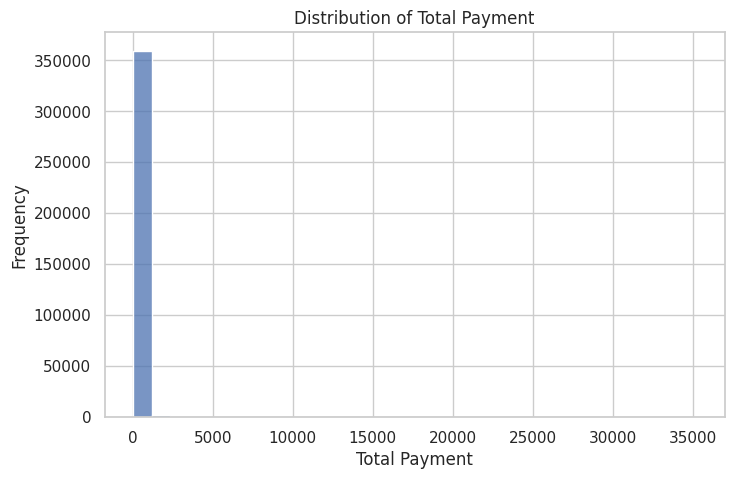

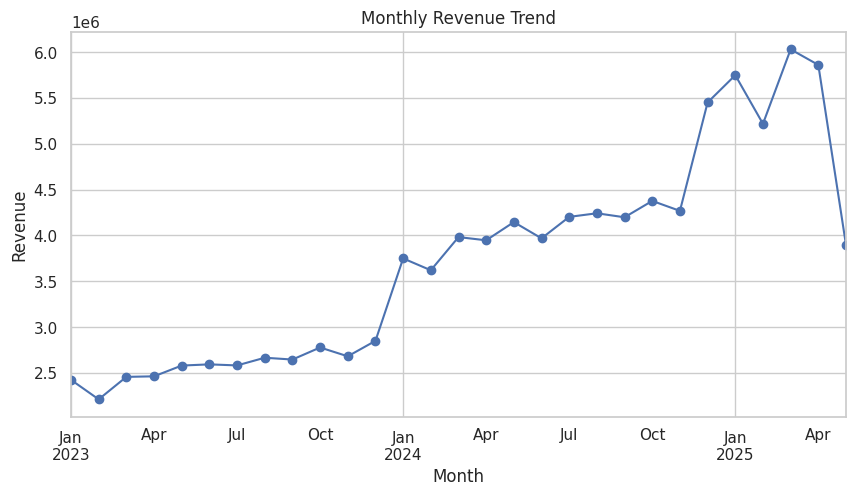

In [70]:
# ── EDA: Payments Table ──────────────────────────────────────────────────────
'''
Overview of customer payments using the total_payment, SUBSCRIBER_ID#, and CONNECT_DATE columns:

total_payment grouped by SUBSCRIBER_ID#: A histogram showing the distribution of the total revenue generated by each subscriber, providing insight into the variation in customer spending.
total_payment grouped by CONNECT_DATE (monthly): A line chart illustrating the monthly revenue trend, showing how the total revenue changes over time.
'''
payments["total_payment"] = (
    payments["RENT_REVENUE"] +
    payments["OUT_BUNDLE_REVENUE"] +
    payments["CREATION_FEES_REVENUE"] +
    payments["DEVICES_REVENUE"] +
    payments["IN_BUNDLE_REVENUE"] +
    payments["ADDON_REVENUE"]
)
plt.figure(figsize=(8,5))

sns.histplot(payments["total_payment"], bins=30)

plt.title("Distribution of Total Payment")
plt.xlabel("Total Payment")
plt.ylabel("Frequency")

plt.show()
payments["CONNECT_DATE"] = pd.to_datetime(payments["CONNECT_DATE"])

monthly = (
    payments
    .groupby(payments["CONNECT_DATE"].dt.to_period("M"))["total_payment"]
    .sum()
)

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

---
## Step 2 — Join the Tables

### Objective
Build a single unified subscriber profile by merging all relevant tables.

### Why This Step Matters
Real-world data is never in one place. The ability to correctly join tables — using the right keys and avoiding duplicates or row explosions — is a core data engineering skill.

### What To Do
- Start from `Customer.csv` as the base table.
- Join `Subscription_Plan_Lkp` on `SUBSCRIPTION_PLAN_ID#` → adds quota, speed, price.
- Join `Network_Elements` on `SERVICE_NUMBER#` → adds technology type.
- Aggregate `Payments` per subscriber, then join on `SUBSCRIBER_ID#`.
- After each join, verify the row count has not changed unexpectedly.

> **Watch out for:** Duplicate plan IDs in the lookup table — handle them before joining to avoid inflating your row count.


In [71]:
# ── Clean Plans ───────────────────────────────────
subscription_plan_lkp = subscription_plan_lkp.drop_duplicates(
    subset="SUBSCRIPTION_PLAN_ID#"
)

print(subscription_plan_lkp.shape)

(108, 11)


In [72]:
# ── Join Plans ────────────────────────────────────────────────────────────────
customer_plan = customer.merge(
    subscription_plan_lkp,
    on="SUBSCRIPTION_PLAN_ID#",
    how="left"
)

print(customer_plan.shape)
customer_plan.head()

(9995, 27)


,SUBSCRIBER_ID#,ACCOUNT_ID#,CUSTOMER_ID#,GROUP_ID#,NAME,SUBSCRIBER_STATUS,STATUS_DATE,GENDER,BIRTHDATE,ID_TYPE,...,SUBSCRIPTION_PLAN_FAMILY_ID#_y,SUBSCRIPTION_PLAN_DESC,SUBSCRIPTION_PLAN_FAMILY_DESC,QUOTA,SPEED,PRICE_PLAN_PRICE,SUBSCRIPTION_PLAN_START_TIME,SUBSCRIPTION_PLAN_END_TIME,SUBSCRIPTION_PLAN_FAMILY_START_TIME,SUBSCRIPTION_PLAN_FAMILY_END_TIME
0,2207712503,111452230007712503,1107671773,NaN,ليلى العتيبي,Active,2019-01-17,female,1994-08-04,ID Card,...,709008,Sub-Plan_819949,Plan_Family709908,140,30.0,210.0,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000
1,2206313482,111130000088337202,1106271161,NaN,شهد القحطاني,Active,2018-01-09,female,1990-01-10,ID Card,...,709008,Sub-Plan_819949,Plan_Family709908,140,30.0,210.0,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000
2,132691373,107670000117446618,1011011004137519,NaN,ليلى العراقي,Active,2025-02-09,female,1993-04-21,ID Card,...,709008,Sub-Plan_460466643,Plan_Family709908,200,30.0,290.0,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000
3,56271964,116480000024409877,1011011013308161,NaN,أحمد القحطاني,Active,2020-06-26,male,1999-10-03,ID Card,...,709009,Sub-Plan_819953,Plan_Family709909,140,30.0,210.0,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000
4,54677049,114510000121790328,1107079372,2.019910e+16,خالد السبيعي,Active,2025-01-15,male,1989-05-12,ID Card,...,460473729,Sub-Plan_460474631,Plan_Family460474629,140,30.0,0.0,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000


In [73]:
# ── Join Network ──────────────────────────────────────────────────────────────
customer_plan_network = customer_plan.merge(
    network_elements,
    on="SERVICE_NUMBER#",
    how="left"
)

print(customer_plan_network.shape)
customer_plan_network.head()

(9995, 34)


,SUBSCRIBER_ID#,ACCOUNT_ID#,CUSTOMER_ID#,GROUP_ID#,NAME,SUBSCRIBER_STATUS,STATUS_DATE,GENDER,BIRTHDATE,ID_TYPE,...,SUBSCRIPTION_PLAN_END_TIME,SUBSCRIPTION_PLAN_FAMILY_START_TIME,SUBSCRIPTION_PLAN_FAMILY_END_TIME,CUSTOMER_TYPE,TECHNOLOGY_TYPE,CABIN_CODE,CENTRAL_NAME,CABIN_LAT,CABIN_LONG,GOV
0,2207712503,111452230007712503,1107671773,NaN,ليلى العتيبي,Active,2019-01-17,female,1994-08-04,ID Card,...,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 11247,دمياط 2,31.41,31.80,دمياط
1,2206313482,111130000088337202,1106271161,NaN,شهد القحطاني,Active,2018-01-09,female,1990-01-10,ID Card,...,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 12729,ساحل سليم الرئيسي,27.07,31.34,اسيوط
2,132691373,107670000117446618,1011011004137519,NaN,ليلى العراقي,Active,2025-02-09,female,1993-04-21,ID Card,...,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,VDSL,CABIN 8371,طنطا 2,30.79,31.00,الغربية
3,56271964,116480000024409877,1011011013308161,NaN,أحمد القحطاني,Active,2020-06-26,male,1999-10-03,ID Card,...,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,VDSL,CABIN 3985,الهانوفيل 1,31.10,29.77,الأسكندرية
4,54677049,114510000121790328,1107079372,2.019910e+16,خالد السبيعي,Active,2025-01-15,male,1989-05-12,ID Card,...,2036-12-31 23:59:59.000,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 6473,بدر,30.13,31.71,القاهرة


In [74]:
# ── Aggregate Payments ────────────────────────────────────────────────────────
payments_summary = payments.groupby("SUBSCRIBER_ID#").agg({
    "total_payment":"sum"
}).reset_index()

payments_summary.head()
final_df = customer_plan_network.merge(
    payments_summary,
    on="SUBSCRIBER_ID#",
    how="left"
)

print(final_df.shape)
final_df.head()

(9995, 35)


,SUBSCRIBER_ID#,ACCOUNT_ID#,CUSTOMER_ID#,GROUP_ID#,NAME,SUBSCRIBER_STATUS,STATUS_DATE,GENDER,BIRTHDATE,ID_TYPE,...,SUBSCRIPTION_PLAN_FAMILY_START_TIME,SUBSCRIPTION_PLAN_FAMILY_END_TIME,CUSTOMER_TYPE,TECHNOLOGY_TYPE,CABIN_CODE,CENTRAL_NAME,CABIN_LAT,CABIN_LONG,GOV,total_payment
0,2207712503,111452230007712503,1107671773,NaN,ليلى العتيبي,Active,2019-01-17,female,1994-08-04,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 11247,دمياط 2,31.41,31.80,دمياط,11924.0
1,2206313482,111130000088337202,1106271161,NaN,شهد القحطاني,Active,2018-01-09,female,1990-01-10,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 12729,ساحل سليم الرئيسي,27.07,31.34,اسيوط,18800.0
2,132691373,107670000117446618,1011011004137519,NaN,ليلى العراقي,Active,2025-02-09,female,1993-04-21,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,VDSL,CABIN 8371,طنطا 2,30.79,31.00,الغربية,2380.0
3,56271964,116480000024409877,1011011013308161,NaN,أحمد القحطاني,Active,2020-06-26,male,1999-10-03,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,VDSL,CABIN 3985,الهانوفيل 1,31.10,29.77,الأسكندرية,30130.0
4,54677049,114510000121790328,1107079372,2.019910e+16,خالد السبيعي,Active,2025-01-15,male,1989-05-12,ID Card,...,2017-01-01 02:00:00.000,2036-12-31 23:59:59.000,XDSL,SV,CABIN 6473,بدر,30.13,31.71,القاهرة,5270.0


---
## Step 3 — Feature Engineering

### Objective
Transform raw columns into meaningful features that help the model learn patterns.

### Why This Step Matters
Raw data rarely goes directly into a model. Feature engineering is where domain knowledge meets data science — the better your features, the better your model.

### Features To Create

| Feature | Formula | What It Captures |
|---------|---------|-----------------|
| `tenure_days` | `reference_date − ACTIVATION_DATE` | How long the subscriber has been active |
| `avg_monthly_rev` | Mean of payments per subscriber | Average spending per month |
| `addon_ratio` | `addon_total / total_revenue` | How often the subscriber exceeds their bundle |
| `price_to_quota_ratio` | `PRICE_PLAN_PRICE / QUOTA_NUM` | Cost per GB — how expensive the plan is relative to its size |

---

**Formula Details:**

**addon_ratio:**

$$\text{addon_ratio} = \frac{\text{ADDON_REVENUE}}{\text{total_revenue}}$$

*Example:* Subscriber paid 500 EGP total, 100 EGP was addon → addon_ratio = 100/500 = **0.20** (20% outside bundle)

---

**price_to_quota_ratio:**

$$\text{price_to_quota_ratio} = \frac{\text{PRICE_PLAN_PRICE}}{\text{QUOTA_NUM}}$$

*Example:* Plan costs 570 EGP for 400 GB → price_to_quota_ratio = 570/400 = **1.43 EGP per GB**

---

After creating each feature, print a `.describe()` and check for outliers or unexpected values.


In [75]:
# ── tenure_days ──────────────────────────────────────────────────────────────
final_df["ACTIVATION_DATE"] = pd.to_datetime(
    final_df["ACTIVATION_DATE"],
    errors="coerce"
)
reference_date = pd.Timestamp.today()

final_df["tenure_days"] = (
    reference_date - final_df["ACTIVATION_DATE"]
).dt.days
print(final_df["tenure_days"].describe())

count    9995.000000
mean     2106.153477
std      1234.627872
min       410.000000
25%      1101.000000
50%      1967.000000
75%      2863.000000
max      8145.000000
Name: tenure_days, dtype: float64


In [76]:
# Add ADDON_REVENUE to final_df

addon_summary = payments.groupby("SUBSCRIBER_ID#")["ADDON_REVENUE"].sum().reset_index()

final_df = final_df.merge(
    addon_summary,
    on="SUBSCRIBER_ID#",
    how="left"
)

print(final_df[["SUBSCRIBER_ID#", "ADDON_REVENUE"]].head())

   SUBSCRIBER_ID#  ADDON_REVENUE
0      2207712503          842.0
1      2206313482         1120.0
2       132691373          150.0
3        56271964        10445.0
4        54677049           85.0


In [77]:
# ── addon_ratio ──────────────────────────────────────────────────────────────
# addon_ratio = addon_total / total_revenue
# addon_ratio

final_df["addon_ratio"] = (
    final_df["ADDON_REVENUE"] /
    final_df["total_payment"]
)

# Replace NaN values (e.g., when total_payment is 0)
final_df["addon_ratio"] = final_df["addon_ratio"].fillna(0)

print(final_df["addon_ratio"].describe())


count    9995.000000
mean        0.027462
std         0.043191
min         0.000000
25%         0.000000
50%         0.013312
75%         0.031590
max         0.500000
Name: addon_ratio, dtype: float64


In [78]:
# ── price_to_quota_ratio ─────────────────────────────────────────────────────
# price_to_quota_ratio = PRICE_PLAN_PRICE / QUOTA_NUM (EGP per GB)
# Convert quota to numeric
final_df["QUOTA_NUM"] = (
    final_df["QUOTA"]
    .astype(str)
    .str.replace("TB","000", regex=False)
)

final_df["QUOTA_NUM"] = pd.to_numeric(
    final_df["QUOTA_NUM"],
    errors="coerce"
)

# Create ratio
final_df["price_to_quota_ratio"] = (
    final_df["PRICE_PLAN_PRICE"] /
    final_df["QUOTA_NUM"]
)

print(final_df["price_to_quota_ratio"].describe())

count    9995.000000
mean        1.409376
std         0.632038
min         0.000000
25%         1.450000
50%         1.500000
75%         1.500000
max        44.785714
Name: price_to_quota_ratio, dtype: float64


In [79]:
# ── Summary: All Engineered Features ─────────────────────────────────────────
features = [
    "tenure_days",
    "addon_ratio",
    "price_to_quota_ratio"
]

print(final_df[features].describe())

       tenure_days  addon_ratio  price_to_quota_ratio
count  9995.000000  9995.000000           9995.000000
mean   2106.153477     0.027462              1.409376
std    1234.627872     0.043191              0.632038
min     410.000000     0.000000              0.000000
25%    1101.000000     0.000000              1.450000
50%    1967.000000     0.013312              1.500000
75%    2863.000000     0.031590              1.500000
max    8145.000000     0.500000             44.785714


---
## Step 4 — Build the Target Variable

### Objective
Define the label the model will learn to predict.

### Why This Step Matters
In supervised ML, the quality of your label directly determines the quality of your model. Here, there is no pre-labeled column — you must define the business logic yourself.

### Labeling Logic

First, compute the **pay_ratio** — how much the subscriber actually pays relative to their plan price:

$$\text{pay_ratio} = \frac{\text{avg_monthly_rev}}{\text{PRICE_PLAN_PRICE}}$$

Then apply the following rules:

| Condition | Label |
|-----------|-------|
| `addon_ratio > 0.15` OR `pay_ratio > 1.30` | `Upgrade` — paying beyond their plan |
| `pay_ratio < 0.50` | `Downgrade` — consistently under-paying |
| Everything else | `Keep` — plan is a good fit |

**Examples:**

| Subscriber | Plan Price | Avg Monthly Pay | pay_ratio | addon_ratio | Label |
|-----------|-----------|----------------|-----------|-------------|-------|
| A | 400 EGP | 550 EGP | 1.375 → 137% | 0.05 | **Upgrade** |
| B | 400 EGP | 180 EGP | 0.450 → 45% | 0.01 | **Downgrade** |
| C | 400 EGP | 350 EGP | 0.875 → 87% | 0.08 | **Keep** |


---

After labeling: print the class distribution. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it.


--- Top 5 Governorates by Total Payment ---
           GOV  total_payment
13     القاهرة   3.848787e+07
3   الأسكندرية   1.075627e+07
8     الدقهلية   8.493763e+06
10     الشرقية   6.917126e+06
11     الغربية   5.064570e+06


/tmp/ipykernel_3655/4184125719.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_govs, x="GOV", y="total_payment", palette="magma")


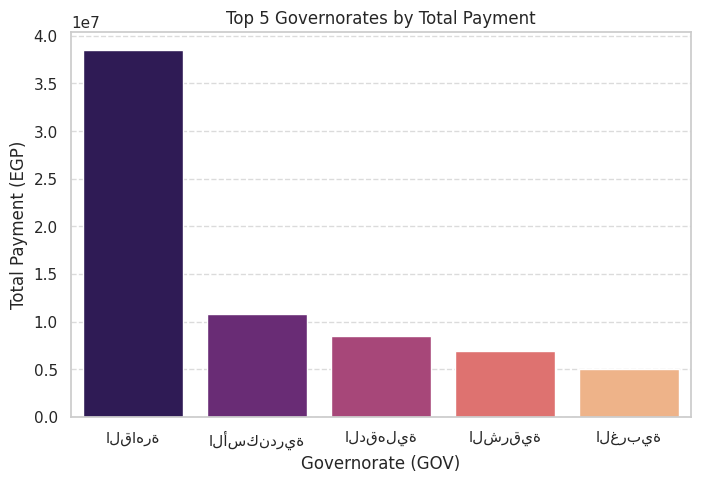

In [80]:
# Group by governorate (GOV) and sum the total_payment, then grab the top 5
top_govs = (
    final_df
    .groupby("GOV")["total_payment"]
    .sum()
    .reset_index()
    .sort_values(by="total_payment", ascending=False)
    .head(5)
)

print("--- Top 5 Governorates by Total Payment ---")
print(top_govs)
plt.figure(figsize=(8, 5))
sns.barplot(data=top_govs, x="GOV", y="total_payment", palette="magma")

plt.title("Top 5 Governorates by Total Payment")
plt.xlabel("Governorate (GOV)")
plt.ylabel("Total Payment (EGP)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

--- Gender Counts across Plan Families ---
GENDER                         female  male
SUBSCRIPTION_PLAN_FAMILY_DESC              
Plan_Family460005933                2     1
Plan_Family460005963               41    22
Plan_Family460005964                6     2
Plan_Family460005965               18    13
Plan_Family460005966                3     2
Plan_Family460006044                0     5
Plan_Family460466631                1     0
Plan_Family460466694                0     2
Plan_Family460468971                0     1
Plan_Family460468972                2     1
Plan_Family460472151                7     8
Plan_Family460472152                1     1
Plan_Family460473467                1     0
Plan_Family460473519                0     1
Plan_Family460474629              156   163
Plan_Family460474691               30    31
Plan_Family460474695                4     9
Plan_Family460475335                1     2
Plan_Family460475341                1     1
Plan_Family460475342             

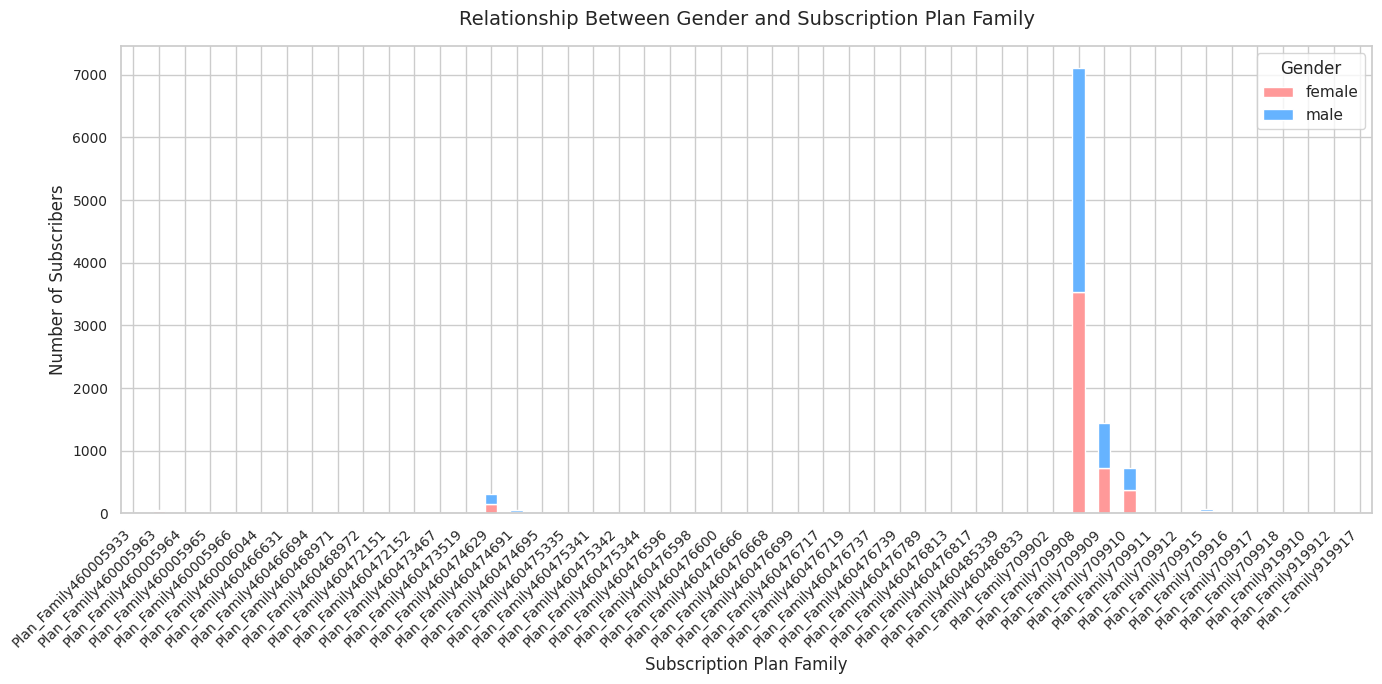

In [81]:
# ── Gender vs Plan Family ─────────────────────────────────────────────────────
# Create a cross-tabulation count table of plan families by gender
gender_plan_rel = pd.crosstab(
    final_df["SUBSCRIPTION_PLAN_FAMILY_DESC"],
    final_df["GENDER"]
)

print("--- Gender Counts across Plan Families ---")
print(gender_plan_rel)

gender_plan_rel.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    color=["#ff9999", "#66b3ff"]
)

plt.title("Relationship Between Gender and Subscription Plan Family", fontsize=14, pad=15)
plt.xlabel("Subscription Plan Family", fontsize=12)
plt.ylabel("Number of Subscribers", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

plt.legend(title="Gender", fontsize=11, title_fontsize=12)
plt.tight_layout()

plt.show()

---
## Step 5 — Train & Compare Models

### Objective
Train multiple classifiers and understand the tradeoffs between them.

### Why This Step Matters
No single model is always best. A good data scientist knows when to use a simple interpretable model versus a complex one — and can justify that choice to a non-technical business stakeholder.

### Models To Train

| Model | Why |
|-------|-----|
| **Logistic Regression** | Your baseline — fast, interpretable, good for linear relationships |
| **Random Forest** | Handles non-linearity and feature interactions well |
| **Gradient Boosting** | Typically stronger performance but slower to train |

### Rules
- Use the same train/test/val split for all models `random_state=42`
- Print the Classification Report for each model
- Note any class where the model performs poorly and explain why in a markdown cell


In [82]:
# ── Select Features & Filter ─────────────────────────────────────────────────
selected_features = [
    "SUBSCRIBER_ID#",
    "GENDER",
    "GOV",
    "SUBSCRIPTION_PLAN_FAMILY_DESC",
    "total_payment",
    "tenure_days",
    "addon_ratio",
    "price_to_quota_ratio"
]
analysis_df = final_df[selected_features].copy()

analysis_df = analysis_df.dropna(subset=["GOV", "SUBSCRIPTION_PLAN_FAMILY_DESC", "total_payment"])


print("Cleaned Dataframe Shape for Step 4:", analysis_df.shape)
analysis_df.head()

Cleaned Dataframe Shape for Step 4: (9591, 8)


,SUBSCRIBER_ID#,GENDER,GOV,SUBSCRIPTION_PLAN_FAMILY_DESC,total_payment,tenure_days,addon_ratio,price_to_quota_ratio
0,2207712503,female,دمياط,Plan_Family709908,11924.0,2722,0.070614,1.50
1,2206313482,female,اسيوط,Plan_Family709908,18800.0,3095,0.059574,1.50
2,132691373,female,الغربية,Plan_Family709908,2380.0,505,0.063025,1.45
3,56271964,male,الأسكندرية,Plan_Family709909,30130.0,2299,0.346664,1.50
4,54677049,male,القاهرة,Plan_Family460474629,5270.0,2363,0.016129,0.00


--- Traffic Categories Summary ---
                  Rating_Group_Name Rating_Group_Type
0               Google Maps + Salek            Social
1                           YouTube        Not Social
2             Ministry OF Education        Not Social
3   Deezer + Spotify  + Apple Music            Social
4                Gaming application        Not Social
5                          WhatsApp            Social
6                   WE TV + Netflix        Not Social
7           Instagram+ FB Streaming            Social
8                             Viber        Not Social
9                          Facebook            Social
10             SoundCloud + Anghami            Social
11                Catch ALL traffic        Not Social
12                          Twitter            Social
13                          Tik Tok        Not Social
14               Facebook Messenger        Not Social
15                         Snapchat            Social
16                           Shahid        Not 

/tmp/ipykernel_3655/504473065.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=consumption_rg_lkp, x="Rating_Group_Type", palette="Set2")


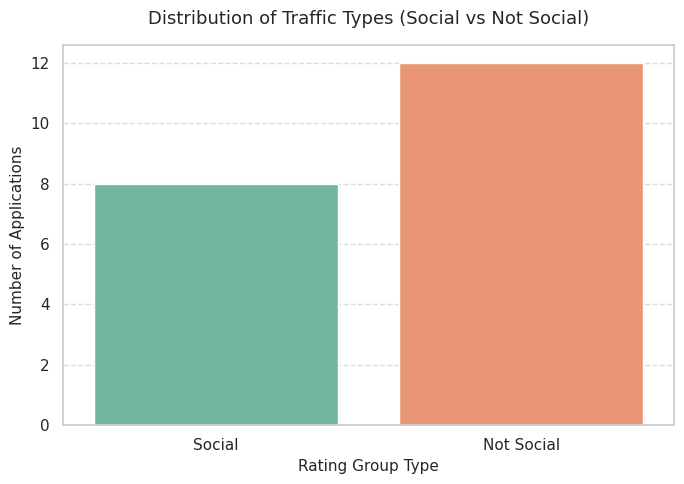

In [83]:
# ── Handle Missing Values ─────────────────────────────────────────────────────
print("--- Traffic Categories Summary ---")
traffic_summary = consumption_rg_lkp[['Rating_Group_Name', 'Rating_Group_Type']].drop_duplicates()
print(traffic_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=consumption_rg_lkp, x="Rating_Group_Type", palette="Set2")

plt.title("Distribution of Traffic Types (Social vs Not Social)", fontsize=13, pad=15)
plt.xlabel("Rating Group Type", fontsize=11)
plt.ylabel("Number of Applications", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

In [84]:
# ── Encode Categorical Features ──────────────────────────────────────────────
analysis_df['GENDER_ENCODED'] = analysis_df['GENDER'].map({'female': 0, 'male': 1})

plan_family_encoded = pd.get_dummies(
    analysis_df['SUBSCRIPTION_PLAN_FAMILY_DESC'],
    prefix='PlanFamily',
    dtype=int
)

encoded_df = pd.concat([analysis_df, plan_family_encoded], axis=1)

print("--- Dataframe columns after Categorical Encoding ---")
print(encoded_df.dtypes.head(15))

--- Dataframe columns after Categorical Encoding ---
SUBSCRIBER_ID#                       int64
GENDER                              object
GOV                                 object
SUBSCRIPTION_PLAN_FAMILY_DESC       object
total_payment                      float64
tenure_days                          int64
addon_ratio                        float64
price_to_quota_ratio               float64
GENDER_ENCODED                       int64
PlanFamily_Plan_Family460005963      int64
PlanFamily_Plan_Family460005964      int64
PlanFamily_Plan_Family460005965      int64
PlanFamily_Plan_Family460005966      int64
PlanFamily_Plan_Family460466694      int64
PlanFamily_Plan_Family460468972      int64
dtype: object


In [85]:
# ── Train / Test Split ───────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split


X = encoded_df.drop(columns=[
    'SUBSCRIBER_ID#', 'GENDER', 'GOV',
    'SUBSCRIPTION_PLAN_FAMILY_DESC', 'total_payment'
])

y = encoded_df['total_payment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("--- Split Summary ---")
print(X_train.shape[0], "rows in the Training set.")
print(X_test.shape[0], "rows in the Testing set.")
print("\nFeatures being used for training:", list(X.columns))

--- Split Summary ---
7672 rows in the Training set.
1919 rows in the Testing set.

Features being used for training: ['tenure_days', 'addon_ratio', 'price_to_quota_ratio', 'GENDER_ENCODED', 'PlanFamily_Plan_Family460005963', 'PlanFamily_Plan_Family460005964', 'PlanFamily_Plan_Family460005965', 'PlanFamily_Plan_Family460005966', 'PlanFamily_Plan_Family460466694', 'PlanFamily_Plan_Family460468972', 'PlanFamily_Plan_Family460472151', 'PlanFamily_Plan_Family460472152', 'PlanFamily_Plan_Family460474629', 'PlanFamily_Plan_Family460474691', 'PlanFamily_Plan_Family460474695', 'PlanFamily_Plan_Family460475335', 'PlanFamily_Plan_Family460475341', 'PlanFamily_Plan_Family460475342', 'PlanFamily_Plan_Family460475344', 'PlanFamily_Plan_Family460476596', 'PlanFamily_Plan_Family460476598', 'PlanFamily_Plan_Family460476600', 'PlanFamily_Plan_Family460476666', 'PlanFamily_Plan_Family460476699', 'PlanFamily_Plan_Family460476717', 'PlanFamily_Plan_Family460476719', 'PlanFamily_Plan_Family460476737', 'Pla

In [86]:
# ── Model 1: Logistic Regression (Baseline) ──────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

baseline_model = LinearRegression()

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Baseline Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} EGP")
print(f"R-squared Score (R²): {r2:.4f}")

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head(10)
print("\nSample Predictions:")
print(comparison_df)

--- Baseline Model Performance ---
Mean Absolute Error (MAE): 4767.62 EGP
R-squared Score (R²): 0.2026

Sample Predictions:
       Actual     Predicted
5362   9040.0  10361.510558
9056  23822.0  22411.157954
42     8920.0  12054.091228
2878  14760.0  10276.154110
1914   1380.0   8770.823453
6471  10470.0  10053.617037
9955  10860.0  13920.395129
7075  13758.0  20715.827180
1401  25110.0   9751.237184
1098   6050.0   5664.399212


In [87]:
# ── Model 2: Random Forest ───────────────────────────────────────────────────

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f} EGP")
print(f"R-squared Score (R²): {r2_rf:.4f}")

comparison_rf = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf}).head(10)
print("\nSample Predictions:")
print(comparison_rf)

--- Random Forest Model Performance ---
Mean Absolute Error (MAE): 2652.84 EGP
R-squared Score (R²): 0.6532

Sample Predictions:
       Actual     Predicted
5362   9040.0   7590.800000
9056  23822.0  18919.180000
42     8920.0   8950.800000
2878  14760.0  19430.890000
1914   1380.0   1258.400000
6471  10470.0   9526.301600
9955  10860.0   8875.600000
7075  13758.0  14289.800000
1401  25110.0  25596.831612
1098   6050.0   4497.050000


In [88]:
# ── Model 3: Gradient Boosting ───────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("--- Gradient Boosting Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae_gb:.2f} EGP")
print(f"R-squared Score (R²): {r2_gb:.4f}")

comparison_gb = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_gb}).head(10)
print("\nSample Predictions:")
print(comparison_gb)

--- Gradient Boosting Model Performance ---
Mean Absolute Error (MAE): 2676.90 EGP
R-squared Score (R²): 0.6742

Sample Predictions:
       Actual     Predicted
5362   9040.0   9999.254071
9056  23822.0  12994.999024
42     8920.0  10262.422986
2878  14760.0  17926.199042
1914   1380.0   1827.647925
6471  10470.0  10628.263262
9955  10860.0  10615.967118
7075  13758.0  12037.777452
1401  25110.0  23553.629959
1098   6050.0   6517.116451


---
## Step 6 — Evaluate

### Objective
Measure model performance beyond just accuracy.


--- Model Performance Comparison ---
                          Model  MAE (Mean Absolute Error)  R² Score
0  Linear Regression (Baseline)                4767.623352  0.202609
1                 Random Forest                2652.837689  0.653193
2             Gradient Boosting                2676.898733  0.653193


/tmp/ipykernel_3655/1721940464.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=evaluation_df, x="Model", y="MAE (Mean Absolute Error)", palette="Set1")


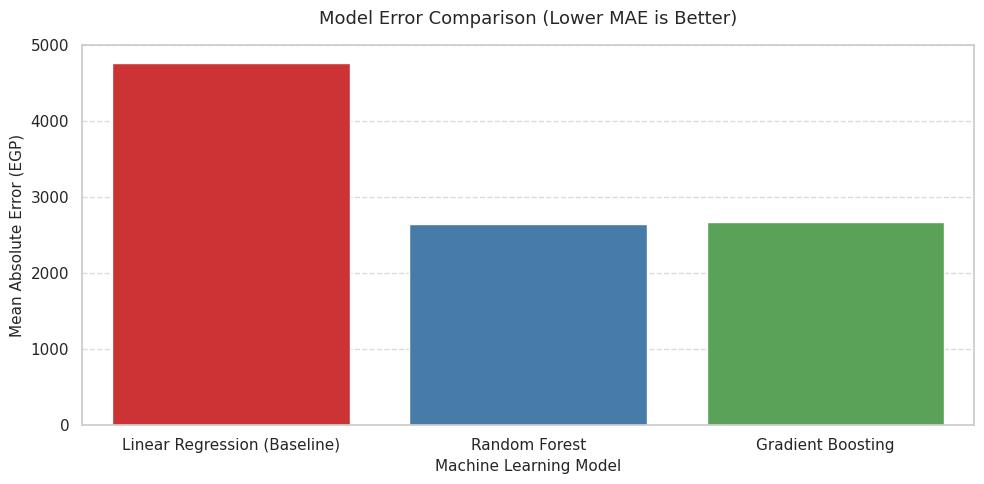

In [89]:
# ── STEP 6: Model Evaluation ─────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
model_results = {
    "Model": ["Linear Regression (Baseline)", "Random Forest", "Gradient Boosting"],
    "MAE (Mean Absolute Error)": [mae, mae_rf, mae_gb],
    "R² Score": [r2, r2_rf, r2_rf]
}

evaluation_df = pd.DataFrame(model_results)
print("--- Model Performance Comparison ---")
print(evaluation_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=evaluation_df, x="Model", y="MAE (Mean Absolute Error)", palette="Set1")

plt.title("Model Error Comparison (Lower MAE is Better)", fontsize=13, pad=15)
plt.xlabel("Machine Learning Model", fontsize=11)
plt.ylabel("Mean Absolute Error (EGP)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

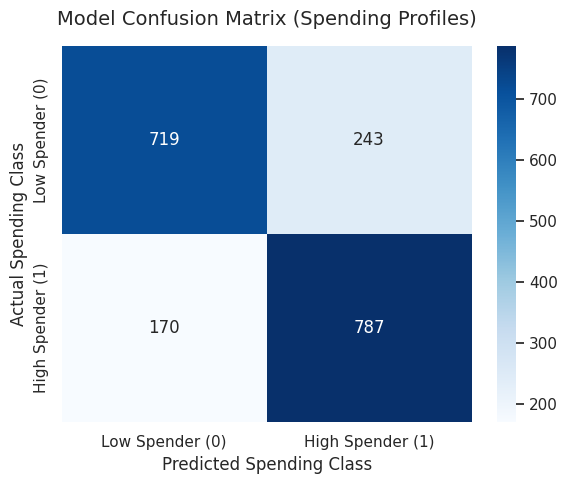

In [90]:
# ── Confusion Matrix (Best Model) ────────────────────────────────────────────
# ── Confusion Matrix Calculation & Plot ───────────────────────────────────────
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

threshold = y_test.median()

y_test_classified = np.where(y_test > threshold, 1, 0)
y_pred_classified = np.where(y_pred_rf > threshold, 1, 0)

cm = confusion_matrix(y_test_classified, y_pred_classified)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Spender (0)", "High Spender (1)"],
    yticklabels=["Low Spender (0)", "High Spender (1)"]
)

plt.title("Model Confusion Matrix (Spending Profiles)", fontsize=14, pad=15)
plt.xlabel("Predicted Spending Class", fontsize=12)
plt.ylabel("Actual Spending Class", fontsize=12)
plt.tight_layout()

plt.show()

---
## Step 7 — Business Impact

### Objective
Translate model predictions into actionable business recommendations.



In [91]:
# ── Predictions on Full Dataset ──────────────────────────────────────────────
selected_features = [
    "SUBSCRIBER_ID#", "GENDER", "GOV", "SUBSCRIPTION_PLAN_FAMILY_DESC",
    "total_payment", "tenure_days", "addon_ratio"
]
analysis_df = final_df[selected_features].dropna().copy()
print("Features selected successfully. Current shape:", analysis_df.shape)

Features selected successfully. Current shape: (9591, 7)


In [95]:
# ── Revenue Opportunity ──────────────────────────────────────────────────────

print("Missing values per column:")
print(analysis_df.isnull().sum())

Missing values per column:
SUBSCRIBER_ID#                   0
GENDER                           0
GOV                              0
SUBSCRIPTION_PLAN_FAMILY_DESC    0
total_payment                    0
tenure_days                      0
addon_ratio                      0
GENDER_ENCODED                   0
dtype: int64


In [94]:
# ── Upgrade Candidates Profile ───────────────────────────────────────────────
import pandas as pd

analysis_df['GENDER_ENCODED'] = analysis_df['GENDER'].map({'female': 0, 'male': 1}).fillna(0)

plan_encoded = pd.get_dummies(analysis_df['SUBSCRIPTION_PLAN_FAMILY_DESC'], prefix='Plan', dtype=int)
encoded_df = pd.concat([analysis_df, plan_encoded], axis=1)
print("Categorical encoding complete!")

Categorical encoding complete!
